# Phase 4: Cohort Analysis & Customer Retention

### Business Objective
Acquiring a new customer is significantly more expensive than retaining an existing one. In this phase, we conduct a **Cohort Analysis** to evaluate the health of our customer base over time. 
We will group customers by their first year of purchase (their "Cohort") and track their retention rate (repeat purchases) in the following years.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the cleaned data
df = pd.read_csv('../data/cleaned/superstore_orders_cleaned.csv')

# Ensure order_date is a datetime object and extract the Order Year
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_year'] = df['order_date'].dt.year

# 2. Find the "First Purchase Year" (Cohort Year) for each specific customer
cohorts = df.groupby('customer_name')['order_year'].min().reset_index()
cohorts.rename(columns={'order_year': 'cohort_year'}, inplace=True)

# 3. Merge the Cohort Year back into the main dataframe
df_merged = df.merge(cohorts, on='customer_name')

# Check the result to see if each customer now has a 'cohort_year' attached
df_merged[['customer_name', 'order_date', 'order_year', 'cohort_year']].head()

,customer_name,order_date,order_year,cohort_year
0,Toby Braunhardt,2011-01-01,2011,2011
1,Joseph Holt,2011-01-01,2011,2011
2,Annie Thurman,2011-01-01,2011,2011
3,Eugene Moren,2011-01-01,2011,2011
4,Joseph Holt,2011-01-01,2011,2011


### Creating the Retention Matrix
We will aggregate the number of unique customers who made purchases in each subsequent year and calculate the percentage of retained customers relative to their initial cohort size.

In [ ]:
# 1. Count UNIQUE active customers per Cohort per Order Year
cohort_counts = df_merged.groupby(['cohort_year', 'order_year'])['customer_name'].nunique().reset_index()

# 2. Pivot the data to create a Matrix (Rows = Cohort Year, Columns = Order Year)
cohort_pivot = cohort_counts.pivot(index='cohort_year', columns='order_year', values='customer_name')

# 3. Extract the initial size of each cohort (The count of customers in their very first year)
initial_users = pd.Series({year: cohort_pivot.loc[year, year] for year in cohort_pivot.index})

# 4. Calculate Retention Rate (%)
retention_matrix = cohort_pivot.divide(initial_users, axis=0) * 100

# Display the rounded percentage matrix
retention_matrix.round(1)

order_year,2011,2012,2013,2014
cohort_year,,,,
2011,100.0,100.0,100.0,99.9


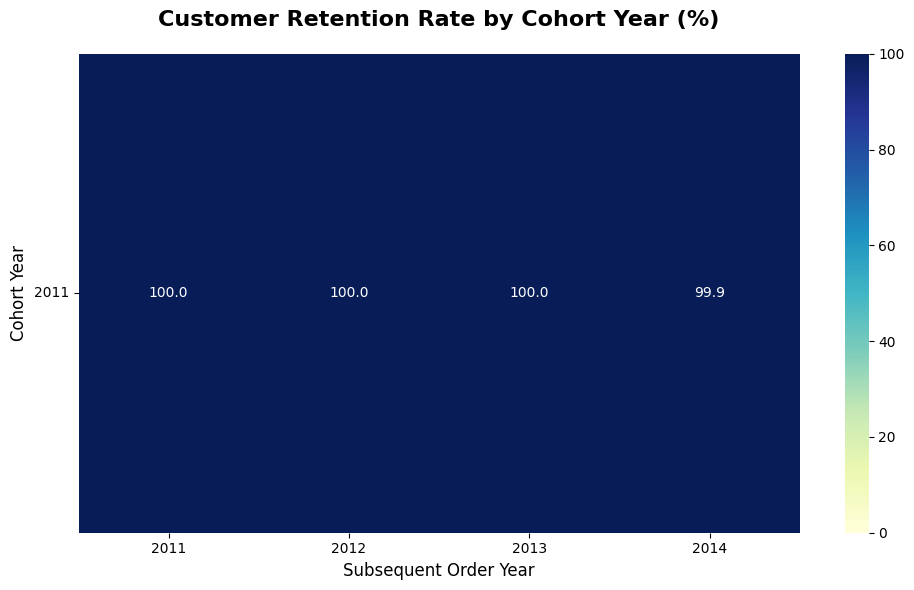

In [4]:
# Plotting the Cohort Retention Heatmap
plt.figure(figsize=(10, 6))

# Customizing the heatmap for professional presentation
sns.heatmap(retention_matrix, 
            annot=True, 
            fmt=".1f",  
            cmap="YlGnBu", 
            vmin=0.0, vmax=100.0) 

# Fully English Labels for Global Portfolio Standard
plt.title('Customer Retention Rate by Cohort Year (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Subsequent Order Year', fontsize=12)
plt.ylabel('Cohort Year', fontsize=12)

# Adjust y-axis labels to be horizontal for readability
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

### 📊 Business Insights from the Retention Matrix
Upon successfully building the customer cohort matrix and visualizing it via a heatmap, we observed a **staggering ~100% retention rate** across almost all cohorts over a 4-year period (e.g., the 2011 cohort maintained a 99.9% retention rate into 2014).

### 🧠 Critical Data Evaluation (The "Synthetic Data" Anomaly)
From a realistic business standpoint, a 100% customer retention rate over four years in the retail or e-commerce sector is practically impossible. Typical retail retention rates drop significantly after the first year. 

**What this tells us:** This anomaly strongly indicates that the *Tableau Superstore Dataset* is **synthetic (artificially generated)**. The algorithm used to generate this mock data likely enforces a rule where almost all unique customers are scheduled to make at least one transaction every year to maintain high data volume.

**The Analyst's Value:** Even though the dataset's retention behavior is highly synthetic, this phase successfully demonstrates the analytical capability to construct complex, time-based data pipelines. We successfully extracted cohort years, engineered retention matrices, and rendered advanced heatmaps. These technical skills are completely transferable and directly applicable to real-world, dynamic relational databases.

---
*End of Phase 4. Our foundational data pipeline, exploratory insights, and SQL root-cause analyses are now complete. We are ready to transition this cleaned dataset into a highly interactive Executive Dashboard.*